In [10]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.chdir('../')
import warnings
import scanpy as sc
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

In [3]:
import anndata as ad

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# the data path
main_dir = '/home/wergillius/Project/diffuse_differentiate/'
data_dir = '/home/wergillius/Project/diffuse_differentiate/data/Fetal_reference/'

In [4]:
def token_labels():
    all_token = pd.read_table(f'{main_dir}data/TFAtlas/tokens.txt',
            sep='\t', names=['TF'])['TF'].values
    token_dict = {token:int(token.split("-")[0].replace("TFORF","")) for token in all_token}
    idx_token_dict = {i:t for t, i in token_dict.items()}
    idx_token_dict[0] = 'TFORF3549-GFP'
    return token_dict, idx_token_dict

In [5]:
token_dict, idx_token_dict = token_labels()

In [6]:
token_dict['TFORF3549-GFP'] = 0

In [7]:
def discrete_time(x):
    x = int(x*250)
    mid_err = np.random.randint(-2,2) # smooth the time
    tail_err = np.random.randint(0,10)
    return min(x, 200-tail_err)

In [8]:
def random_split(adata):
    trainval, test = train_test_split(adata.obs.index, test_size=0.1)
    train, val = train_test_split(trainval, test_size=0.1)

    adata.obs['split'] = 'o'

    adata.obs.loc[train ,'split'] = 'train'
    adata.obs.loc[val ,'split'] = 'val'
    adata.obs.loc[test ,'split'] = 'test'

In [13]:
adata_diff = sc.read_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")

(array([3.2000e+01, 4.8400e+02, 5.4530e+03, 1.2962e+04, 6.6810e+03,
        2.2610e+03, 7.4700e+02, 1.6200e+02, 3.5000e+01, 8.0000e+00]),
 array([-587.72271729, -440.13272095, -292.54272461, -144.95272827,
           2.63726807,  150.2272644 ,  297.81726074,  445.40725708,
         592.99725342,  740.58728027,  888.17724609]),
 <BarContainer object of 10 artists>)

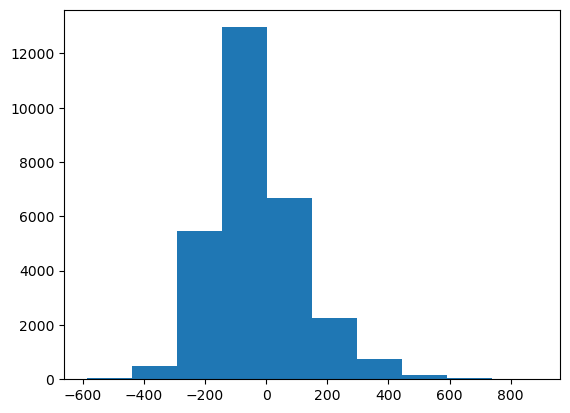

In [14]:
plt.hist(adata_diff.X.sum(axis=1))

In [10]:
adata_diff.var['highly_variable'].sum()

4806

In [16]:
adata_diff.obsm['X_diffmap'].shape

(28825, 15)

In [23]:
adata_diff.obs.head()

,TF,batch,louvain,n_counts,n_genes,percent_mito
"R1.11,R2.75,R3.53,P1.54-0-1-0",TFORF3021-DLX4,0,6,5272.0,3114,0.020106
"R1.57,R2.65,R3.85,P1.62-1-1-0",TFORF3021-DLX4,0,0,4635.0,2871,0.031284
"R1.36,R2.43,R3.03,P1.07-2-1-0",TFORF3021-DLX4,0,0,7828.0,4022,0.022100
"R1.30,R2.78,R3.32,P1.31-1-2-0",TFORF3021-DLX4,0,1,2149.0,1654,0.024663
"R1.87,R2.31,R3.93,P1.31-1-2-0",TFORF3021-DLX4,0,3,2960.0,2056,0.016554


In [25]:
tf_distribution = adata_diff.obs.groupby('TF').agg('count')['n_genes']

In [ ]:
tf_distribution

In [ ]:
token_dict, idx_token_dict = 

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


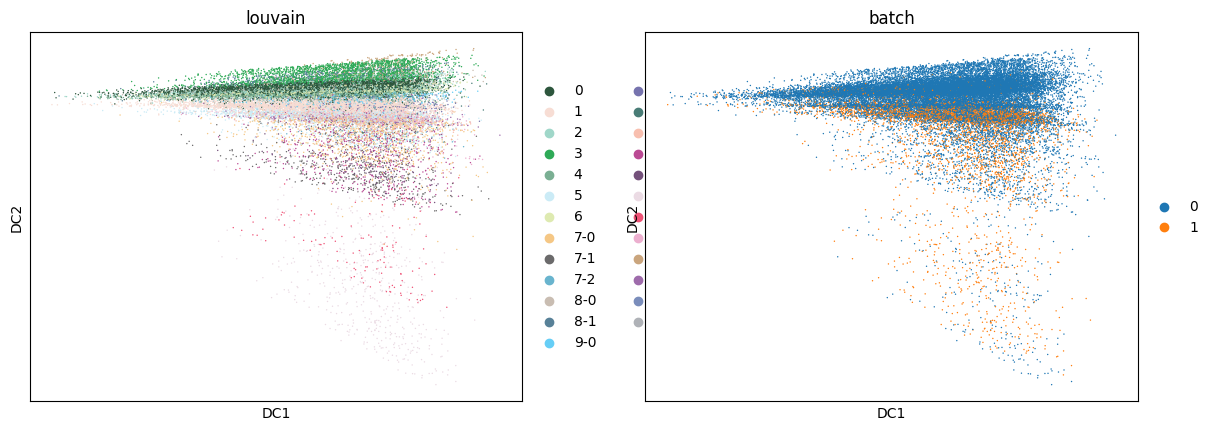

In [19]:
sc.pl.diffmap(adata_diff, color=['louvain','batch'])

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


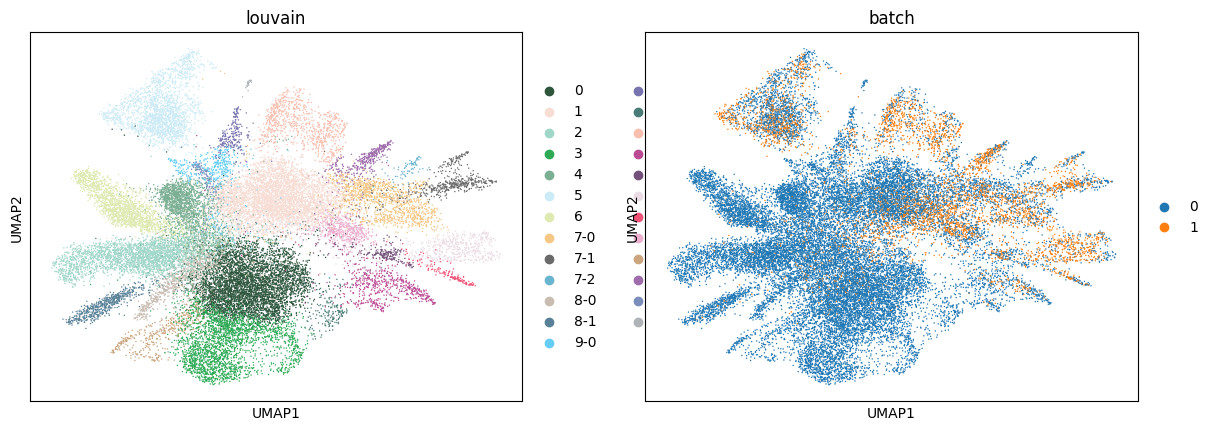

In [26]:
sc.pl.umap(adata_diff, color=['louvain','batch'])

In [27]:
sc.tl.dpt(adata_diff, n_branchings=0, n_dcs=10)

In [63]:
adata_diff.obsp['connectivities']

<28825x28825 sparse matrix of type '<class 'numpy.float64'>'
	with 693196 stored elements in Compressed Sparse Row format>

<Axes: ylabel='Frequency'>

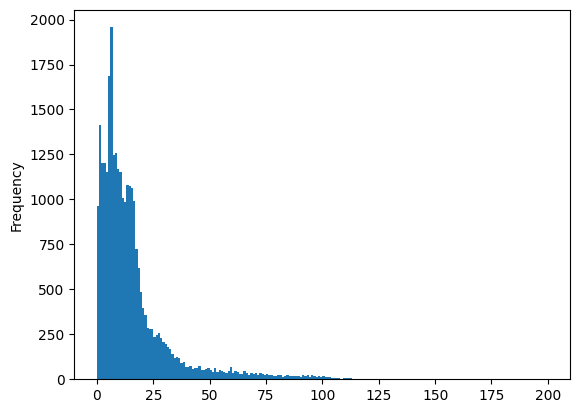

In [30]:
adata_diff.obs['discrete_time'].plot(kind='hist', bins=200)

In [33]:
random_split(adata_diff)

In [29]:
adata_diff.obs['discrete_time'] = adata_diff.obs.dpt_pseudotime.apply(discrete_time)

In [54]:
adata_diff.uns['unique_token_dict'] = token_dict

In [58]:
max(token_dict.values())

3550

In [59]:
len(token_dict.values())

3369

In [55]:
adata_diff.write_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")

In [65]:
adata_diff.X.max(axis=0)

array([10.       , 10.       ,  4.163133 , ..., 10.       ,  4.145881 ,
        3.6173196], dtype=float32)

# sub TF

In [24]:
adata_subTF = sc.read_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_subsample.h5ad")

# adata_subTF.obs.reset_index(inplace=True)
# adata_subTF.obs.rename({"index":"cellbarcode"},axis=1,inplace=True)

In [ ]:
random_split(adata_subTF)

In [ ]:
adata_subTF.obs['discrete_time'] = adata_subTF.obs.dpt_pseudotime.apply(discrete_time)

In [72]:
adata_subTF

AnnData object with n_obs × n_vars = 671453 × 3517
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'v_pseudotime', 'split', 'discrete_time'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'diffmap_evals', 'draw_graph', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'umap', 'unique_token_dict'
    obsm: 'NMF', 'X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

<Axes: ylabel='Frequency'>

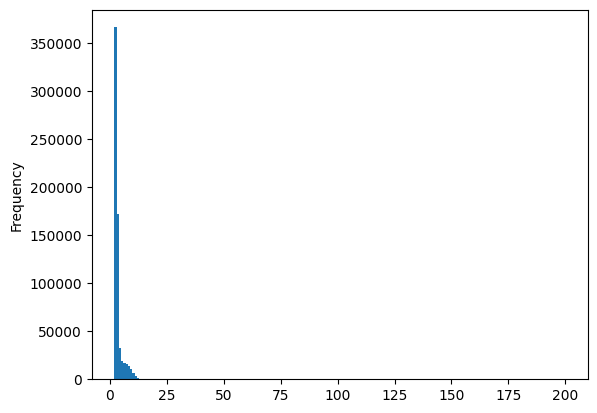

In [71]:
adata_subTF.obs['discrete_time'].plot(kind='hist', bins=200)

In [69]:
adata_subTF.uns['unique_token_dict'] = token_dict

In [77]:
sc.pp.neighbors(adata_subTF, n_neighbors=20, n_pcs=30)

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [79]:
adata_subTF.write_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_subsample.h5ad")

In [9]:
adata_subTF.obsm['NMF'][:10,:]

array([[ 1.99865231e-02,  0.00000000e+00,  1.04033165e-01,
         2.71576460e-02,  4.32203888e-02,  3.77825124e-02,
         5.50229877e-03,  4.85447989e-03,  1.06399313e-02,
         5.24101674e-03,  1.08450411e-02,  0.00000000e+00,
         6.72470213e-03,  0.00000000e+00,  1.07022381e-02,
         0.00000000e+00,  0.00000000e+00,  7.39722389e-03,
         0.00000000e+00,  4.97078270e-03,  0.00000000e+00,
         2.61181617e-03,  2.46834324e-03,  0.00000000e+00,
         9.30641512e-03,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.37201137e-02,  0.00000000e+00,
         3.03785675e-02,  0.00000000e+00,  3.73221411e-02,
         5.65022042e-03,  0.00000000e+00,  1.78796701e-02,
         7.14930323e-03,  2.64598391e-02,  0.00000000e+00,
         0.00000000e+00,  3.70097240e-03,  0.00000000e+00,
         8.24700246e-03,  0.00000000e+00,  1.95610877e-02,
         5.23657224e-02,  0.00000000e+00,  0.00000000e+00,
         2.41011259e-02,  0.00000000e+00,  0.00000000e+0

# select TF that are enriched in diff and also incoporate real starting cells

In [13]:
TF_sum  = adata_diff.obs.groupby("TF").agg({"louvain":"count"})

In [73]:

filter = 20
print(np.sum(TF_sum.louvain >= filter))
TF_sum.query("`louvain` >= @filter").sum()

481


louvain    18829
dtype: int64

In [74]:
Diff_TFs = TF_sum.query("`louvain` >= @filter").index
print(Diff_TF[:4])

CategoricalIndex(['TFORF0015-DRAP1', 'TFORF0022-IRX3', 'TFORF0032-GSC2',
                  'TFORF0037-SP5'],
                 categories=['TFORF0001-HIF3A', 'TFORF0002-HIF3A', 'TFORF0003-HIF3A', 'TFORF0005-HIF3A', 'TFORF0007-TULP4', 'TFORF0008-ZNF709', 'TFORF0009-ZNF708', 'TFORF0010-ZNF879', ...], ordered=False, dtype='category', name='TF')


In [82]:
Diff_TFs = list(Diff_TFs)
diff_adata_cb = adata_diff.obs.query("`TF` in @Diff_TFs").index

### find the starting cells

In [26]:
adata_subTF.raw.X.shape

(671453, 37528)

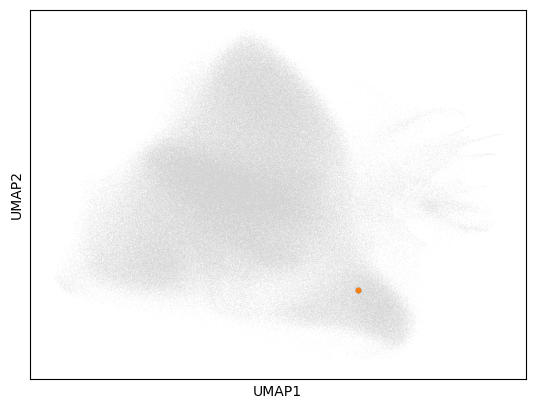

In [47]:
root=adata_subTF.uns['iroot']

fig = sc.pl.umap(adata_subTF, return_fig=True, show=False)
fig.gca().scatter( x=adata_subTF.obsm['X_umap'][root,0], 
            y=adata_subTF.obsm['X_umap'][root,1], s=10)

fig

In [51]:
adata_subTF.obs.iloc[root][['TF', 'louvain']]

TF         TFORF3550-mCherry
louvain                    4
Name: R1.51,R2.32,R3.48,P1.30-1-1, dtype: object

In [54]:
control_TF = ['TFORF3549-GFP','TFORF3550-mCherry']

In [57]:
control_cb = adata_subTF.obs.query("`louvain` == '4' & `TF` in @control_TF").index

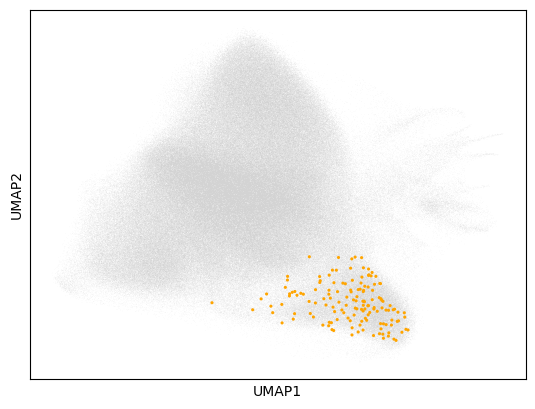

In [66]:
fig = sc.pl.umap(adata_subTF, return_fig=True, show=False)
sc.pl.umap(adata_subTF[control_cb], return_fig=False,
            ax = fig.gca(), size=20 , na_color='orange')

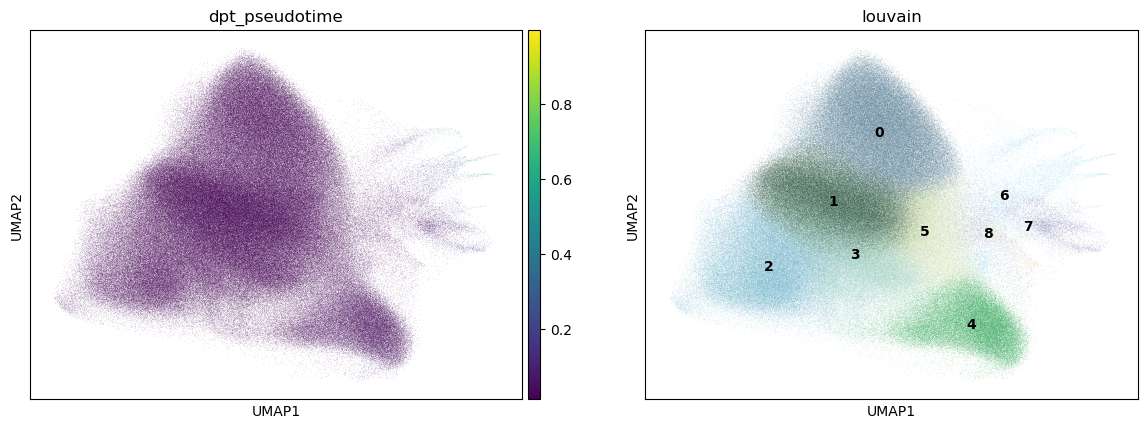

In [84]:
sc.pl.umap(adata_subTF, color=['dpt_pseudotime', 'louvain'], legend_loc='on data')

In [80]:
adata_subTF[control_cb].obs['dpt_pseudotime'].max()

0.04285553867049748

# Create two comb_s_adata datasets

In [26]:
comb_cb = list(diff_adata_cb) + list(control_cb)

NameError: name 'diff_adata_cb' is not defined

In [27]:
comb_cb = comb_s_adata.obs_names

In [28]:
comb_s_ad_fromsub = adata_subTF[comb_cb].copy()
comb_s_obs = adata_subTF[comb_cb].copy().obs

In [97]:
X = comb_s_adata.raw[:,adata_diff.var_names].X

In [107]:
X.dtype

dtype('float32')

In [115]:
comb_s_adata = ad.AnnData(X=X, obs=comb_s_obs.copy(), var = adata_diff.var.copy())
comb_s_adata.uns['unique_token_dict'] = adata_diff.uns['unique_token_dict']

In [29]:
comb_s_adata.obsm['X_pca_harmony'] = comb_s_ad_fromsub.obsm['X_pca_harmony']

### assign metadata

In [141]:
comb_s_adata.obs['Start_group'] = False
comb_s_adata.obs.loc[control_cb, 'Start_group'] = True

In [17]:
comb_s_adata.obs['cell_type'] = meta_df.loc[diff_adata_cb, 'predicted.id']
comb_s_adata.obs['cell_type'].fillna('Control', inplace=True)

In [7]:
import pandas as pd
meta_df = pd.read_csv(f"{main_dir}some_tutorials/TF-atlas/Figure3B_celltype_mapping.csv")

In [6]:
comb_s_adata = sc.read_h5ad(f"{main_dir}/data/TFAtlas/DiffTF_control_Small.h5ad")

In [11]:
total_counts = comb_s_adata.X.sum(axis=1)

In [ ]:
sc.tl.pca(comb_s_adata, n_comps=50)

In [42]:
sc.pp.neighbors(comb_s_adata, n_neighbors=20)

In [43]:
sc.tl.umap(comb_s_adata, min_dist = 0.5, maxiter=500, spread=1)

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


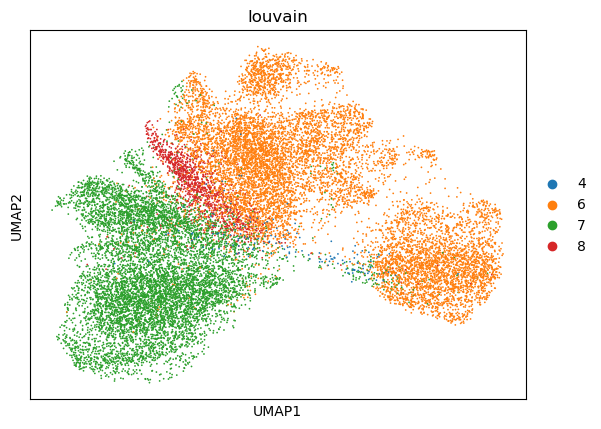

In [44]:
sc.pl.umap(comb_s_adata, color=['louvain'])


In [70]:
select = np.logical_and(comb_s_adata.obsm['X_umap'][:,0] > 0, 
        comb_s_adata.obsm['X_umap'][:,0] <2)

select = np.logical_and(select,
                comb_s_adata.obsm['X_umap'][:,1] < 4
        )

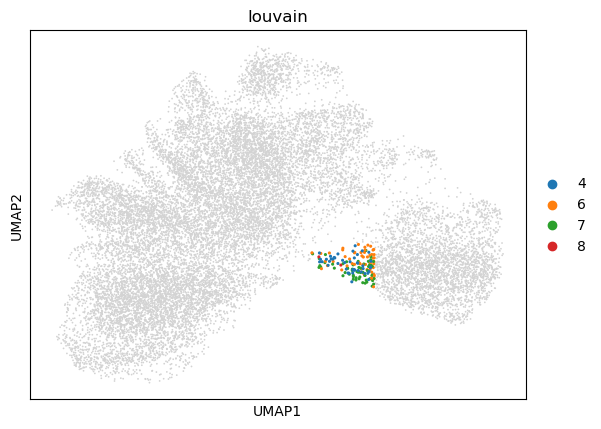

In [71]:
fig = sc.pl.umap(comb_s_adata, return_fig=True)
ax = fig.gca()
sc.pl.umap(comb_s_adata[select], size=20, color=['louvain'], ax=ax)


In [1]:
control_TF = ['TFORF3549-GFP','TFORF3550-mCherry']
cb = comb_s_adata[select].obs.query("`TF` in @control_TF & `Start_group` == False ")

NameError: name 'comb_s_adata' is not defined

In [77]:
cb

Index(['R1.34,R2.93,R3.46,P1.38-2-1', 'R1.90,R2.33,R3.69,P1.22-0-1',
       'R1.59,R2.62,R3.65,P1.62-3-1'],
      dtype='object')

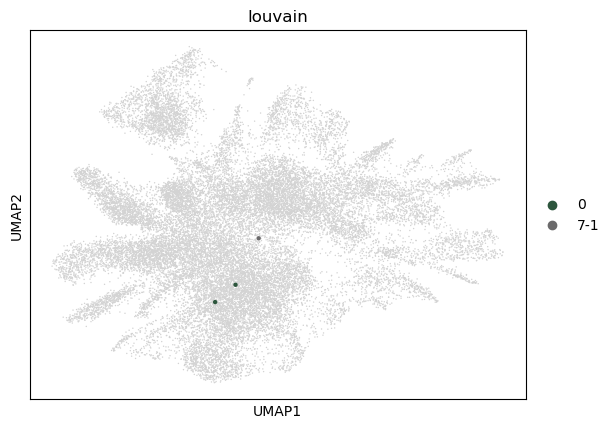

In [79]:
fig = sc.pl.umap(adata_diff, return_fig=True)
ax = fig.gca()
sc.pl.umap(adata_diff[cb], size=40, color=['louvain'], ax=ax)


In [ ]:
scipy.sparse.csgraph.dijkstra

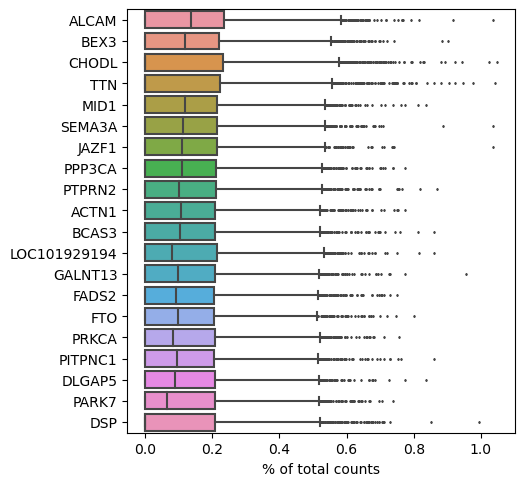

In [26]:
sc.pl.highest_expr_genes(comb_s_adata, n_top=20, )

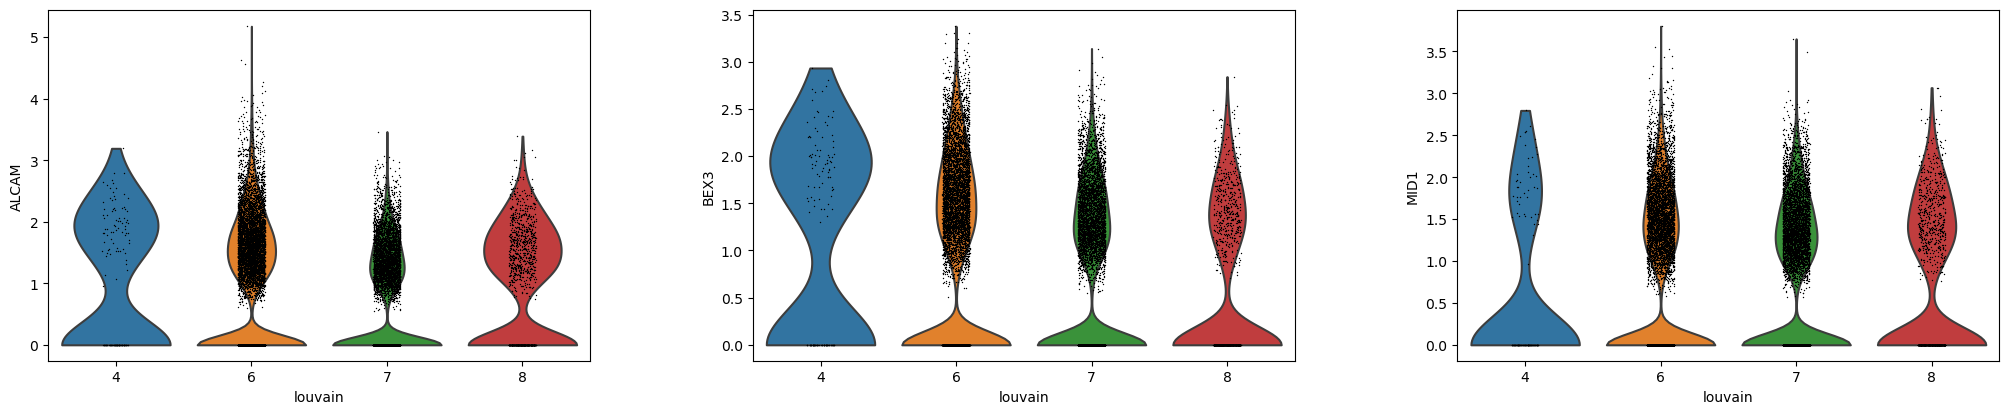

In [29]:
sc.pl.violin(comb_s_adata, ['ALCAM', 'BEX3', 'MID1'], groupby='louvain')

In [143]:
comb_s_adata.write_h5ad(f"{main_dir}/data/TFAtlas/DiffTF_control_Small.h5ad")

### large control + TFs

In [86]:
# diff_TF cbs
selected_cluster = ['4', '5', '6','7','8']
diff_TF_cbs = adata_subTF.obs.query('`TF` in @Diff_TFs & `louvain` in @selected_cluster').index
print(len(diff_TF_cbs))

95866


In [ ]:
# downsample some cells
diff_TF_cbs = adata_subTF.obs.query('`TF` in @Diff_TFs & `louvain` in @selected_cluster').index